PREDICTIVE MODELING - DATASET LOADING
Dataset Shape: (7043, 21)
Number of Features: 20
Number of Samples: 7043

First 5 rows:
   Dependents  Tenure Months  Paperless Billing  Monthly Charges  \
0   -0.548093      -1.236724           0.829798        -0.362660   
1    1.824507      -1.236724           0.829798         0.197365   
2    1.824507      -0.992402           0.829798         1.159546   
3    1.824507      -0.177995           0.829798         1.330711   
4    1.824507       0.677133           0.829798         1.294151   

   Total Charges  Avg_Monthly_Charge  Internet Service_Fiber optic  \
0      -0.958066           -0.350966                           0.0   
1      -0.938874            0.367602                           1.0   
2      -0.643789            1.250946                           1.0   
3       0.338085            1.456605                           1.0   
4       1.216150            1.258186                           1.0   

   Internet Service_No  Online Security_No i

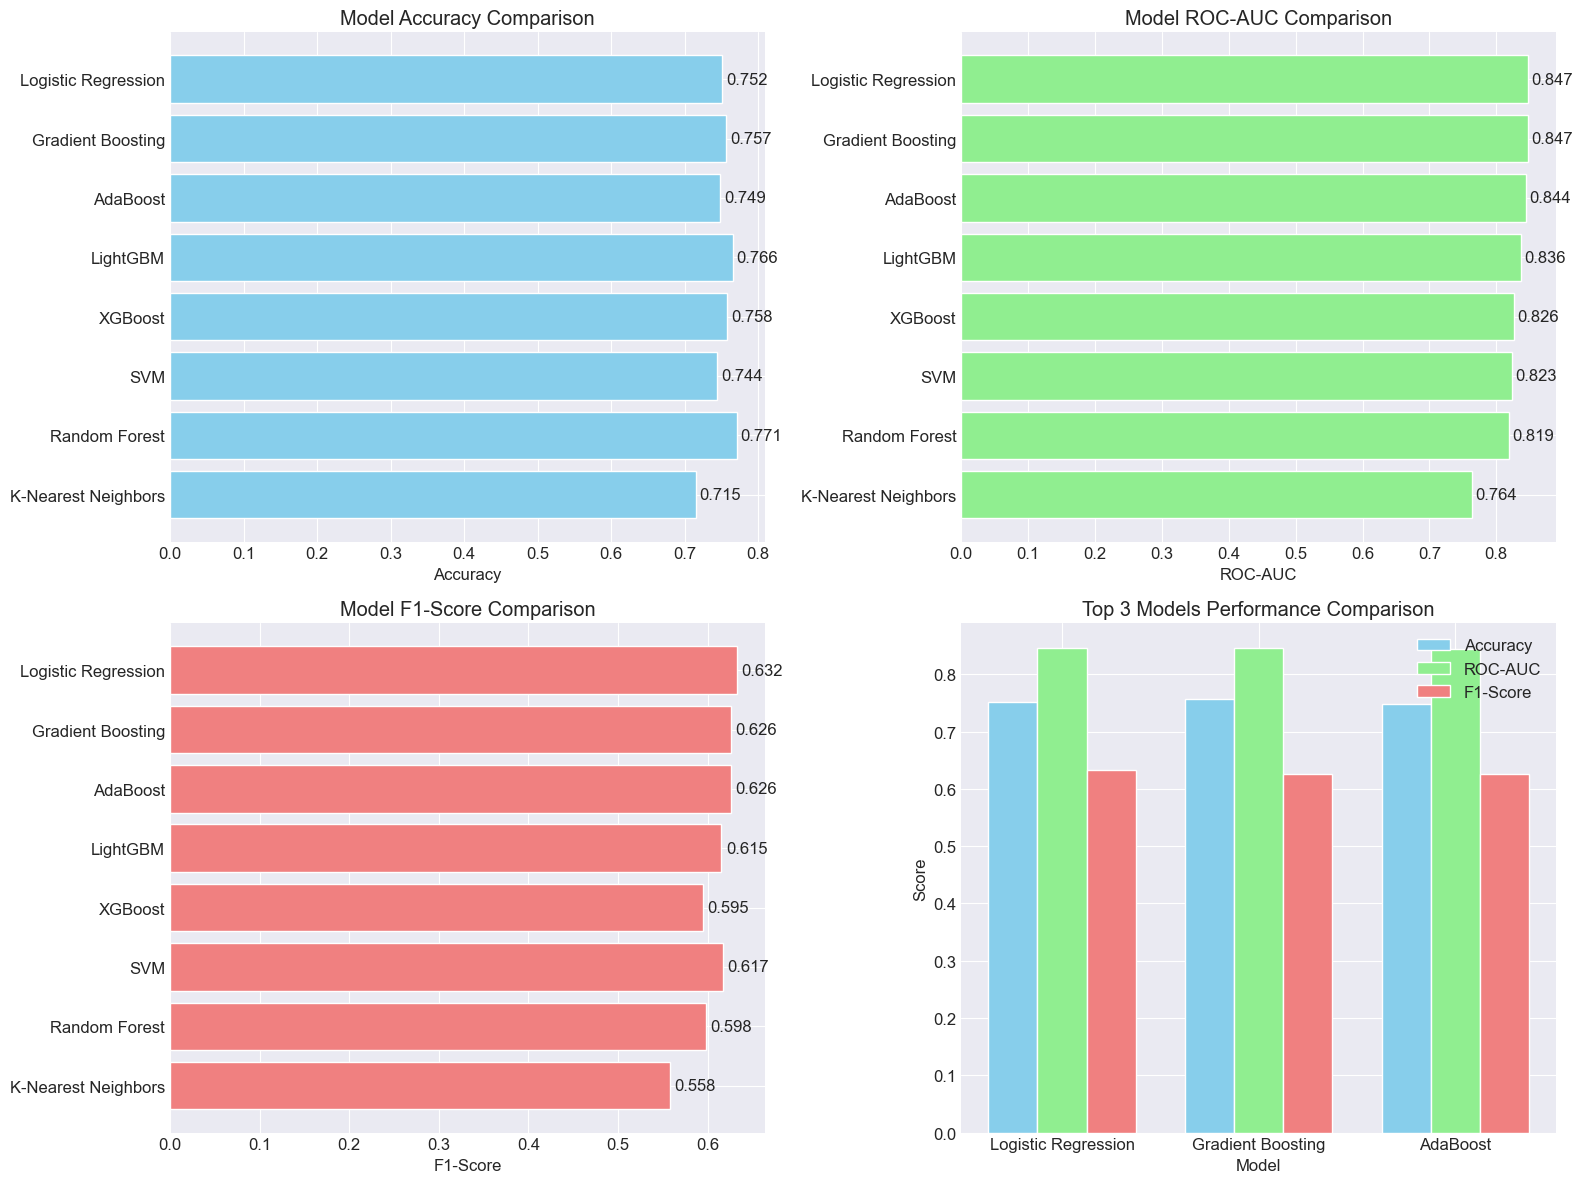


Model comparison results saved to '../reports_2/model_performance_comparison.csv'

HYPERPARAMETER TUNING
Selected models for tuning: ['Logistic Regression', 'Gradient Boosting', 'AdaBoost']

Tuning Gradient Boosting...
  Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
  Best CV score: 0.8577
  Test ROC-AUC: 0.8468

TUNED VS UNTUNED MODELS COMPARISON
                       Model  Version  Accuracy   ROC-AUC  F1-Score
2                   AdaBoost  Untuned  0.748758  0.844443  0.625793
1          Gradient Boosting  Untuned  0.756565  0.846839  0.625954
3  Gradient Boosting (Tuned)    Tuned  0.756565  0.846839  0.625954
0        Logistic Regression  Untuned  0.751597  0.847070  0.632353

Hyperparameter tuning results saved to '../reports_2/hyperparameter_tuning_results.csv'

BEST MODEL SELECTION & EVALUATION
Best Model: Logistic Regression
ROC-AUC: 0.8471
Accuracy: 0.7516
F1-Score: 0.6324


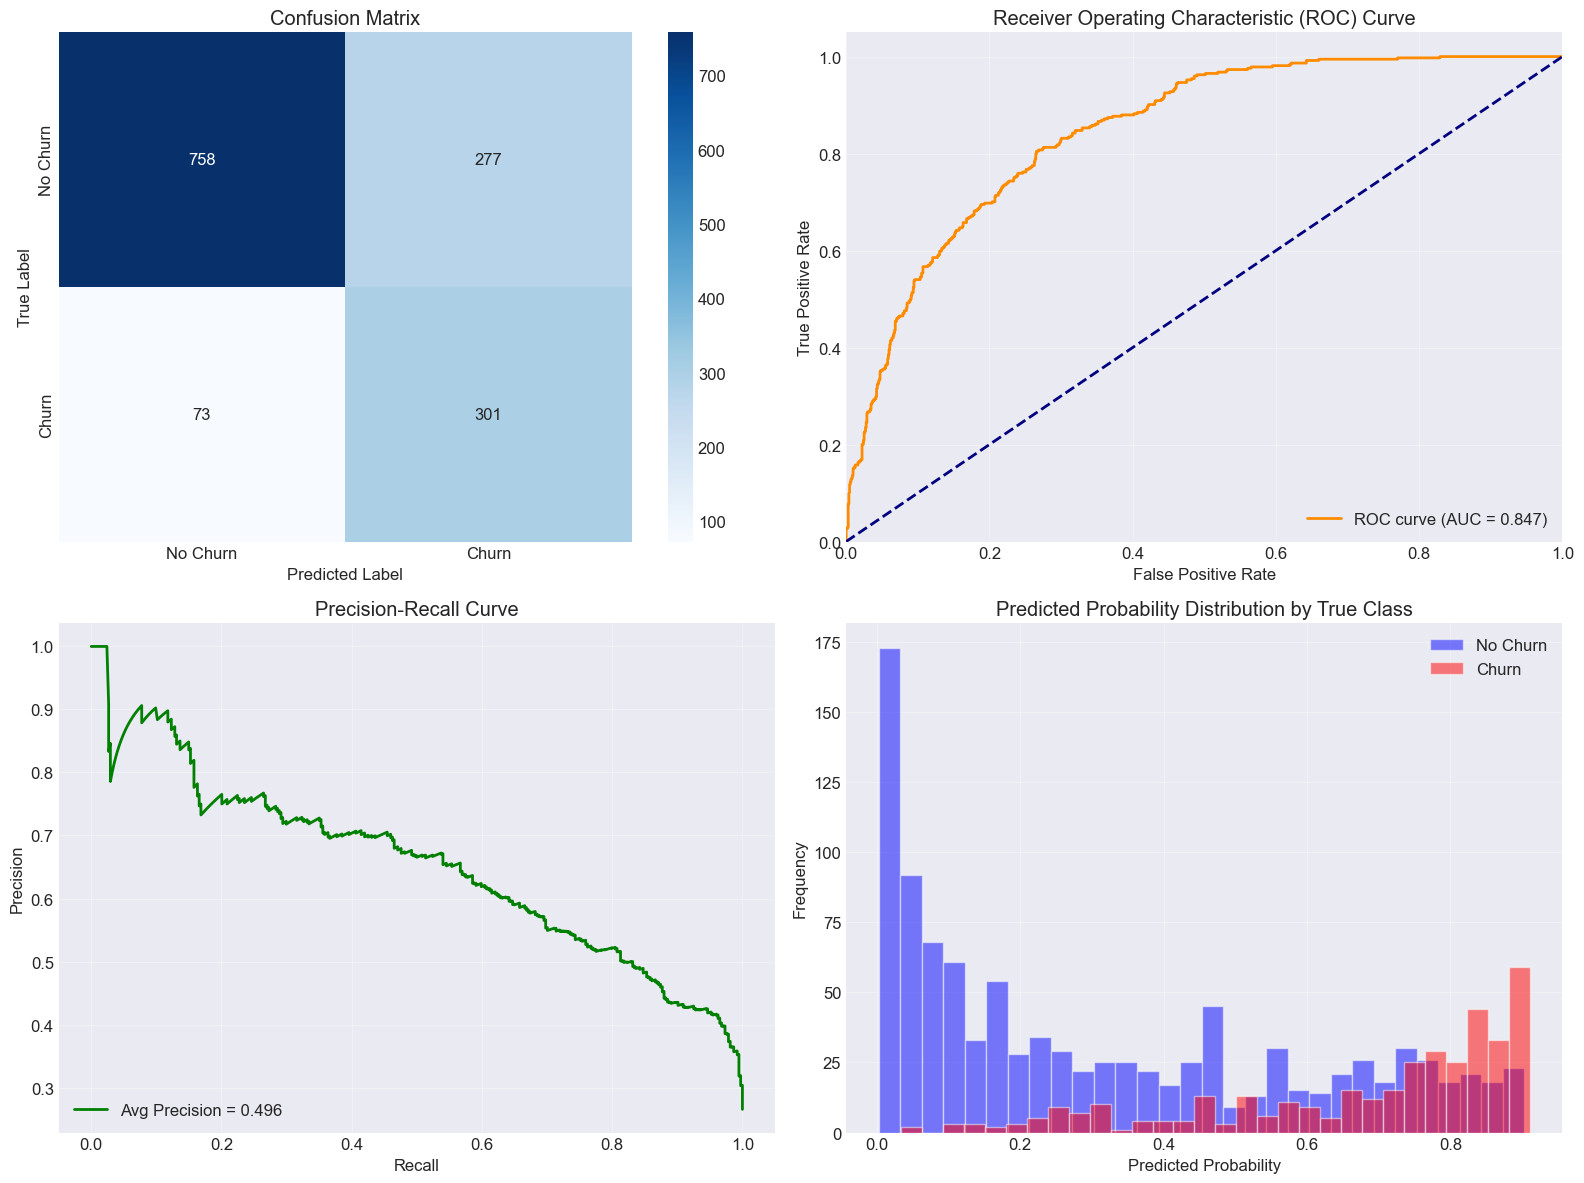


Evaluation visualizations saved to '../reports_2/best_model_evaluation.png'

MODEL SAVING & DEPLOYMENT
Best model saved to: ../models_2/best_churn_model_final.pkl
Model metadata saved to: ../models_2/model_metadata_final.json
Predictions saved to: ../reports_2/final_predictions.csv

BUSINESS INSIGHTS & RECOMMENDATIONS

BUSINESS INSIGHTS REPORT

1. BUSINESS CONTEXT:
   - Total Customers: 7,043
   - Current Churn Rate: 26.5%
   - Churning Customers: 1,869
   - Average Monthly Revenue per Customer: $50

2. MODEL PERFORMANCE:
   - Best Model: Logistic Regression
   - Accuracy: 75.2%
   - Precision: 52.1% (of predicted churns, how many actually churn)
   - Recall: 80.5% (of actual churns, how many we correctly predict)
   - ROC-AUC: 0.847

3. PREDICTION ANALYSIS:
   - True Positives (Correctly predicted churns): 301
   - False Positives (Incorrectly predicted as churn): 277
   - False Negatives (Missed churns): 73
   - True Negatives (Correctly predicted non-churns): 758

4. FINANCIAL IMPA

In [2]:
# Telco Customer Churn - Predictive Modeling

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_recall_curve, f1_score, roc_curve,
    precision_score, recall_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import json

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Load processed data
print("="*60)
print("PREDICTIVE MODELING - DATASET LOADING")
print("="*60)

df = pd.read_csv('../data/processed_features.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1] - 1}")  # Subtract target column
print(f"Number of Samples: {df.shape[0]}")
print("\nFirst 5 rows:")
print(df.head())

# Separate features and target
print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

# Split data into train and test sets
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

# Handle class imbalance
print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE")
print("="*60)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Training set: {X_train.shape}")
print(f"Before SMOTE - Class distribution: \n{y_train.value_counts()}")
print(f"\nAfter SMOTE - Training set: {X_train_resampled.shape}")
print(f"After SMOTE - Class distribution: \n{pd.Series(y_train_resampled).value_counts()}")

# Initialize models
print("\n" + "="*60)
print("MODEL INITIALIZATION")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

print(f"Total models to train: {len(models)}")
for name, model in models.items():
    print(f"- {name}")

# Train and evaluate models
print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Create pipeline with SMOTE
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string())

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(results_df)), results_df['Accuracy'].values, color='skyblue')
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels(results_df['Model'])
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.invert_yaxis()
for i, v in enumerate(results_df['Accuracy'].values):
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center')

# Plot 2: ROC-AUC comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(results_df)), results_df['ROC-AUC'].values, color='lightgreen')
ax2.set_yticks(range(len(results_df)))
ax2.set_yticklabels(results_df['Model'])
ax2.set_xlabel('ROC-AUC')
ax2.set_title('Model ROC-AUC Comparison')
ax2.invert_yaxis()
for i, v in enumerate(results_df['ROC-AUC'].values):
    ax2.text(v + 0.005, i, f'{v:.3f}', va='center')

# Plot 3: F1-Score comparison
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(results_df)), results_df['F1-Score'].values, color='lightcoral')
ax3.set_yticks(range(len(results_df)))
ax3.set_yticklabels(results_df['Model'])
ax3.set_xlabel('F1-Score')
ax3.set_title('Model F1-Score Comparison')
ax3.invert_yaxis()
for i, v in enumerate(results_df['F1-Score'].values):
    ax3.text(v + 0.005, i, f'{v:.3f}', va='center')

# Plot 4: Top 3 models comparison
ax4 = axes[1, 1]
top_3 = results_df.head(3)
x_pos = np.arange(len(top_3))
width = 0.25

ax4.bar(x_pos - width, top_3['Accuracy'].values, width, label='Accuracy', color='skyblue')
ax4.bar(x_pos, top_3['ROC-AUC'].values, width, label='ROC-AUC', color='lightgreen')
ax4.bar(x_pos + width, top_3['F1-Score'].values, width, label='F1-Score', color='lightcoral')

ax4.set_xlabel('Model')
ax4.set_ylabel('Score')
ax4.set_title('Top 3 Models Performance Comparison')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(top_3['Model'])
ax4.legend()

plt.tight_layout()
plt.savefig('../reports_2/model_comparison_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results
results_df.to_csv('../reports_2/model_performance_comparison.csv', index=False)
print("\nModel comparison results saved to '../reports_2/model_performance_comparison.csv'")

# Hyperparameter tuning for best models
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Select top 3 models for tuning
top_models = results_df.head(3)['Model'].tolist()
print(f"Selected models for tuning: {top_models}")

# Define parameter grids
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5],
        'classifier__subsample': [0.8, 1.0]
    }
}

tuned_models = {}
tuning_results = []

for model_name in top_models:
    if model_name in param_grids:
        print(f"\nTuning {model_name}...")
        
        # Get base model
        base_model = models[model_name]
        
        # Create pipeline
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', base_model)
        ])
        
        # Grid search
        grid_search = GridSearchCV(
            pipeline,
            param_grids[model_name],
            cv=5,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        
        # Best model
        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        
        # Evaluate
        y_pred = best_model.predict(X_test)
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        
        tuning_results.append({
            'Model': f"{model_name} (Tuned)",
            'Best Params': str(grid_search.best_params_),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
        })
        
        print(f"  Best parameters: {grid_search.best_params_}")
        print(f"  Best CV score: {grid_search.best_score_:.4f}")
        print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Compare tuned vs untuned models
print("\n" + "="*60)
print("TUNED VS UNTUNED MODELS COMPARISON")
print("="*60)

# Get untuned results for comparison
untuned_comparison = results_df[results_df['Model'].isin(top_models)].copy()
untuned_comparison['Version'] = 'Untuned'

# Create tuned comparison DataFrame
tuned_comparison_df = pd.DataFrame(tuning_results)
tuned_comparison_df['Version'] = 'Tuned'

# Combine
comparison_df = pd.concat([untuned_comparison, tuned_comparison_df], ignore_index=True)

# Sort for better visualization
comparison_df['Model_Base'] = comparison_df['Model'].str.replace(' \\(Tuned\\)', '', regex=True)
comparison_df = comparison_df.sort_values(['Model_Base', 'Version'], ascending=[True, False])

print(comparison_df[['Model', 'Version', 'Accuracy', 'ROC-AUC', 'F1-Score']].to_string())

# Save tuning results
tuned_comparison_df.to_csv('../reports_2/hyperparameter_tuning_results.csv', index=False)
print("\nHyperparameter tuning results saved to '../reports_2/hyperparameter_tuning_results.csv'")

# Select and evaluate best model
print("\n" + "="*60)
print("BEST MODEL SELECTION & EVALUATION")
print("="*60)

# Get best model (considering both tuned and untuned)
all_results_comparison = pd.concat([results_df, tuned_comparison_df], ignore_index=True)
best_model_row = all_results_comparison.loc[all_results_comparison['ROC-AUC'].idxmax()]
best_model_name = best_model_row['Model']

print(f"Best Model: {best_model_name}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"F1-Score: {best_model_row['F1-Score']:.4f}")

# Determine which model to use
if '(Tuned)' in best_model_name:
    base_model_name = best_model_name.replace(' (Tuned)', '')
    best_pipeline = tuned_models[base_model_name]
else:
    # Create pipeline with best untuned model
    best_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', models[best_model_name])
    ])
    best_pipeline.fit(X_train, y_train)

# Make final predictions
y_pred_final = best_pipeline.predict(X_test)
y_pred_proba_final = best_pipeline.predict_proba(X_test)[:, 1]

# Detailed evaluation
print("\n" + "="*60)
print("DETAILED EVALUATION METRICS")
print("="*60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix:")
print(cm)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print("\nAdditional Metrics:")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")
print(f"False Positive Rate: {fp/(fp+tn) if (fp+tn) > 0 else 0:.4f}")
print(f"False Negative Rate: {fn/(fn+tp) if (fn+tp) > 0 else 0:.4f}")

# Visualizations
print("\n" + "="*60)
print("VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix Heatmap
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_xticklabels(['No Churn', 'Churn'])
ax1.set_yticklabels(['No Churn', 'Churn'])

# Plot 2: ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
roc_auc = roc_auc_score(y_test, y_pred_proba_final)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC) Curve')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_final)
avg_precision = np.mean(precision)
ax3.plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.3f}')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance or Probability Distribution
ax4 = axes[1, 1]
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_importance = best_pipeline.named_steps['classifier'].feature_importances_
    feature_names = X.columns
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).head(15)
    
    # Plot
    bars = ax4.barh(range(len(importance_df)), importance_df['Importance'].values, color='purple')
    ax4.set_yticks(range(len(importance_df)))
    ax4.set_yticklabels(importance_df['Feature'])
    ax4.set_xlabel('Importance')
    ax4.set_title('Top 15 Feature Importance')
    ax4.invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(importance_df['Importance'].values):
        ax4.text(v + 0.001, i, f'{v:.3f}', va='center')
    
    # Save feature importance
    importance_df.to_csv('../reports_2/feature_importance_final.csv', index=False)
    print("\nFeature importance saved to '../reports_2/feature_importance_final.csv'")
else:
    # If no feature importance, plot probability distribution
    ax4.hist(y_pred_proba_final[y_test == 0], bins=30, alpha=0.5, label='No Churn', color='blue')
    ax4.hist(y_pred_proba_final[y_test == 1], bins=30, alpha=0.5, label='Churn', color='red')
    ax4.set_xlabel('Predicted Probability')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Predicted Probability Distribution by True Class')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports_2/best_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation visualizations saved to '../reports_2/best_model_evaluation.png'")

# Save the best model
print("\n" + "="*60)
print("MODEL SAVING & DEPLOYMENT")
print("="*60)

# Save the best model
model_path = '../models_2/best_churn_model_final.pkl'
joblib.dump(best_pipeline, model_path)
print(f"Best model saved to: {model_path}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': type(best_pipeline.named_steps['classifier']).__name__,
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance_metrics': {
        'accuracy': float(best_model_row['Accuracy']),
        'roc_auc': float(best_model_row['ROC-AUC']),
        'f1_score': float(best_model_row['F1-Score']),
        'precision': float(best_model_row['Precision']),
        'recall': float(best_model_row['Recall'])
    },
    'feature_names': X.columns.tolist(),
    'dataset_info': {
        'total_samples': len(df),
        'churn_rate': float(y.mean()),
        'feature_count': X.shape[1]
    }
}

# Save metadata
metadata_path = '../models_2/model_metadata_final.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Model metadata saved to: {metadata_path}")

# Save predictions for analysis
predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_final,
    'probability': y_pred_proba_final
})
predictions_path = '../reports_2/final_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to: {predictions_path}")

# Generate business insights
print("\n" + "="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

# Calculate business metrics
total_customers = len(df)
churn_customers = y.sum()
churn_rate = y.mean() * 100

# Model performance metrics
model_accuracy = best_model_row['Accuracy']
model_recall = best_model_row['Recall']
model_precision = best_model_row['Precision']

# Calculate potential impact
predicted_churn = y_pred_final.sum()
true_positives = tp
false_positives = fp

# Assume average customer value (this would come from business data)
avg_customer_value = 50  # Monthly revenue per customer
retention_cost_per_customer = 10  # Cost to retain a customer

# Calculate financial impact
potential_savings = true_positives * avg_customer_value * 12  # Annual savings
retention_costs = (true_positives + false_positives) * retention_cost_per_customer
net_savings = potential_savings - retention_costs

insights = f"""
BUSINESS INSIGHTS REPORT
=========================

1. BUSINESS CONTEXT:
   - Total Customers: {total_customers:,}
   - Current Churn Rate: {churn_rate:.1f}%
   - Churning Customers: {churn_customers:,}
   - Average Monthly Revenue per Customer: ${avg_customer_value}

2. MODEL PERFORMANCE:
   - Best Model: {best_model_name}
   - Accuracy: {model_accuracy:.1%}
   - Precision: {model_precision:.1%} (of predicted churns, how many actually churn)
   - Recall: {model_recall:.1%} (of actual churns, how many we correctly predict)
   - ROC-AUC: {best_model_row['ROC-AUC']:.3f}

3. PREDICTION ANALYSIS:
   - True Positives (Correctly predicted churns): {true_positives:,}
   - False Positives (Incorrectly predicted as churn): {false_positives:,}
   - False Negatives (Missed churns): {fn:,}
   - True Negatives (Correctly predicted non-churns): {tn:,}

4. FINANCIAL IMPACT ANALYSIS:
   Assuming we intervene with all predicted churners:
   - Potential Annual Revenue Saved: ${potential_savings:,.0f}
   - Retention Program Cost: ${retention_costs:,.0f}
   - NET ANNUAL SAVINGS: ${net_savings:,.0f}
   - ROI: {(net_savings/retention_costs*100 if retention_costs > 0 else 0):.0f}%

5. STRATEGIC RECOMMENDATIONS:

   A. TARGETED RETENTION STRATEGIES:
      1. Focus on customers with month-to-month contracts
      2. Implement loyalty programs for long-term customers
      3. Offer special retention offers to high-value customers

   B. SERVICE IMPROVEMENTS:
      1. Enhance customer service for internet service users
      2. Bundle services to increase switching costs
      3. Improve technical support response times

   C. PRICING STRATEGIES:
      1. Review pricing for customers with high monthly charges
      2. Offer family plans for customers with dependents
      3. Implement graduated pricing based on tenure

   D. OPERATIONAL ACTIONS:
      1. Proactively contact customers identified as high-risk
      2. Train customer service to recognize churn signals
      3. Monitor model performance monthly

6. NEXT STEPS:
   - Deploy model in production environment
   - Set up automated churn alerts
   - Track intervention success rates
   - Retrain model quarterly with new data
"""

print(insights)

# Save insights to file
insights_path = '../reports_2/business_insights_report.txt'
with open(insights_path, 'w') as f:
    f.write(insights)
print(f"\nBusiness insights report saved to: {insights_path}")

# Cross-validation
print("\n" + "="*60)
print("CROSS-VALIDATION")
print("="*60)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std CV ROC-AUC: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Final summary
print("\n" + "="*60)
print("PREDICTIVE MODELING - FINAL SUMMARY")
print("="*60)

summary = f"""
PREDICTIVE MODELING COMPLETED SUCCESSFULLY
==========================================

1. DATA PREPARATION:
   - Processed dataset with {X.shape[1]} features and {len(X)} samples
   - Churn rate: {y.mean()*100:.1f}%
   - Train-Test split: {X_train.shape[0]} training, {X_test.shape[0]} test samples

2. MODEL DEVELOPMENT:
   - Evaluated {len(models)} different algorithms
   - Performed hyperparameter tuning on top {len(top_models)} models
   - Selected best model: {best_model_name}

3. MODEL PERFORMANCE:
   - Test Accuracy: {best_model_row['Accuracy']:.1%}
   - Test ROC-AUC: {best_model_row['ROC-AUC']:.3f}
   - Test F1-Score: {best_model_row['F1-Score']:.3f}
   - Cross-validation ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}

4. OUTPUTS GENERATED:
   - Best model saved: models_2/best_churn_model_final.pkl
   - Model metadata: models_2/model_metadata_final.json
   - Performance reports_2: reports_2/ folder
   - Business insights: reports_2/business_insights_report.txt
   - Visualizations: Multiple .png files in reports_2/ folder

5. BUSINESS VALUE:
   - Model can identify {true_positives} churning customers with {model_precision:.1%} precision
   - Potential annual savings: ${net_savings:,.0f}
   - ROI: {(net_savings/retention_costs*100 if retention_costs > 0 else 0):.0f}%

6. NEXT STEPS FOR DEPLOYMENT:
   1. Integrate model with customer database
   2. Set up automated scoring pipeline
   3. Create dashboard for customer success team
   4. Monitor model performance monthly
   5. Retrain model quarterly

PROJECT COMPLETED SUCCESSFULLY!
"""

print(summary)

# Save final summary
summary_path = '../reports_2/predictive_modeling_summary.txt'
with open(summary_path, 'w') as f:
    f.write(summary)
print(f"\nFinal summary saved to: {summary_path}")